## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# lees de dataset in
df = pd.read_csv("data/Advertising.csv")

In [3]:
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


### Features en labels splitsen

In [4]:
# X: alles uitgezonderd de y / het label
X = df.drop('sales',axis=1)
y = df['sales']

## Polynomiale Regressie

**We transformeren onze originele dataset door het toevoegen van extra features!**

We vertrekken van: (hier voorbeeld met 1 feature) 

$$\hat{y} = \theta_0 + \theta_1x_1 + \epsilon $$

en we voegen extra features toe vertrekkend van de originele x feature voor een bepaalde graad *d* van een polynoom

$$\hat{y} = \theta_0 + \theta_1x_1 + \theta_1x^2_1 +  ... + \theta_dx^d_1 + \epsilon$$

Dan passen we het lineaire regressie model toe, aangezien we in werkelijkheid gewoon deze nieuwe polynomiale features x^2, x^3, ... x^d als nieuwe features behandelen.  Het spreekt voor zich dat we voorzichtig moeten zijn bij het bepalen van de graad van de polynoom. Onze resultaten op de test set zullen hierbij helpen!

**Het dient opgemerkt te worden dat we hier meerdere X features hebben, niet één enkele zoals in de formule hierboven.  In werkelijkheid zal PolynomialFeatures ook interactietermen in rekening brengen.**

In [5]:
from sklearn.preprocessing import PolynomialFeatures

In [6]:
# help(PolynomialFeatures)

In [7]:
# instance aanmaken van PolynomialFeatures
# we willen de bias term niet omdat we achteraf lineaire regressie gaan toepassen
polynomial_converter = PolynomialFeatures(degree=2, include_bias=False)

In [8]:
# Converter "fits" to data, in this case, reads in every X column
# Then it "transforms" and ouputs the new polynomial data
poly_features = polynomial_converter.fit_transform(X) # kan apart .fit(X) en .transform(X)

In [9]:
poly_features.shape

(200, 9)

Is dit zoals we verwachten? Check de shape van de originele dataset:

In [10]:
X.shape

(200, 3)

Het is logisch dat we 200 rijen terugkrijgen.  Eerste waarde van X:

In [11]:
X.iloc[0]

TV           230.1
radio         37.8
newspaper     69.2
Name: 0, dtype: float64

In [12]:
# en de poly features:
poly_features[0]

array([2.301000e+02, 3.780000e+01, 6.920000e+01, 5.294601e+04,
       8.697780e+03, 1.592292e+04, 1.428840e+03, 2.615760e+03,
       4.788640e+03])

In [13]:
# waar komen deze vandaan?
poly_features[0][:3]

array([230.1,  37.8,  69.2])

In [14]:
poly_features[0][:3]**2

array([52946.01,  1428.84,  4788.64])

De interactietermen: $$x_1  \cdot x_2 \text{  en  } x_1  \cdot x_3 \text{  en  }   x_2  \cdot x_3 $$

In [15]:
230.1*37.8

8697.779999999999

In [16]:
230.1*69.2

15922.92

In [17]:
37.8*69.2

2615.7599999999998

## Train | Test Split

We gaan nu het polynomiale model trainen en de performantie vergelijken met ons initieel model.

We hebben hiervoor de polynomial converter gezien.  Hiermee gaan we van 3 features naar 9 features.  Als we later een nieuw datapunt (in ons geval 3 features) inlezen, moeten we dit ook converteren naar de 9 features gebruik makend van de polynomial converter.  Dit betekent dat deze converter moet worden opgeslagen om later datapunten te kunnen converteren.   

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
# op welke dataset doen we train_test_split? 
# waardes voor test_size en random_state identiek als bij LR om te kunnen vergelijken!
X_train, X_test, y_train, y_test = train_test_split(poly_features, y, test_size=0.3, random_state=101)

In [29]:
# Scaler van de data best altijd, vooral bij Ridge or Lasso aparte modellen,
# maar kan zeker geen kwaad bij LR ook niet
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

### Model om te fitten op Polynomiale Data

#### Maak een instantie van het model

In [30]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

### Fit/Train het model op de training data

**Fit enkel op de training data om zeker te zijn dat je later de performantie van het model goed kan evalueren**

In [31]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False



## Evaluatie op de Test Set

### Bereken de performantie op de test set

We willen een correcte evaluatie van ons model, dus we berekenen onze performantie op basis van de test set - data die het model niet heeft gezien.

In [32]:
test_pred = model.predict(X_test)

In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [34]:
print(f"MAE = {mean_absolute_error(test_pred, y_test):.2f}")
print(f"MSE = {mean_squared_error(test_pred, y_test):.2f}")

MAE = 0.49
MSE = 0.44


In [36]:
mean_absolute_error(test_pred, y_test)

0.4896798044803571

In [37]:
mean_squared_error(test_pred, y_test)

0.4417505510403404

In [39]:
RMSE = np.sqrt(mean_squared_error(test_pred, y_test))
RMSE

np.float64(0.6646431757269011)

In [40]:
df['sales'].mean()

np.float64(14.0225)

In [41]:
# Welk model presteert beter?
# Check de coëfficiënten van het model:
model.coef_

array([ 4.35694035,  0.19292482,  0.25690957, -2.82073059,  3.7782365 ,
       -0.27172285,  0.02422714,  0.13425441, -0.05457998])

In [42]:
poly_features[0]

array([2.301000e+02, 3.780000e+01, 6.920000e+01, 5.294601e+04,
       8.697780e+03, 1.592292e+04, 1.428840e+03, 2.615760e+03,
       4.788640e+03])

In [44]:
X.iloc[0]

TV           230.1
radio         37.8
newspaper     69.2
Name: 0, dtype: float64

## Welke graad is nu de beste?  Over- en underfitting!

### Keuze van het model

### Aanpassen van de parameters

Zijn we tevreden met de performantie?  Kan een complexer model (hogere orde polynoom in dit geval) de performantie verder verhogen?  Hoe complex is te complex?  

We gaan ons model trainen met telkens een hogere orde polynoom, en de errors opslaan.  Dit kunnen we dan gebruiken om na te gaan hoe complex ons model mag worden.

We runnen een loop die het volgende doet:
1. Maak X data van een telkens hogere orde polynoom
2. Splits de data voor train/test
3. Fit op de training data
4. Bewaar de resultaten van train en test data metrics

Daarna plotten we deze resultaten en zien we of en wanneer overfitting optreedt

In [45]:
# TRAINING ERROR PER GRAAD
train_rmse_errors = []
# TEST ERROR PER GRAAD
test_rmse_errors = []

for d in range(1,10):    
    # MAAK POLY DATA SET VOOR GRAAD "d"
    polynomial_converter = PolynomialFeatures(degree=d,include_bias=False)
    poly_features = polynomial_converter.fit_transform(X)
    
    # SPLITS DE DATASET
    X_train, X_test, y_train, y_test = train_test_split(poly_features, y, test_size=0.3, random_state=101)
    
    # TRAIN OP DEZE NIEUWE POLY SET
    model = LinearRegression(fit_intercept=True)
    model.fit(X_train,y_train)
    
    # VOORSPEL OP TRAIN EN TEST SET
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    # BEREKEN DE ERRORS
    
    # Errors op Train Set
    train_RMSE = np.sqrt(mean_squared_error(y_train,train_pred))
    
    # Errors op Test Set
    test_RMSE = np.sqrt(mean_squared_error(y_test,test_pred))

    # Append errors aan lists om later te plotten
    train_rmse_errors.append(train_RMSE)
    test_rmse_errors.append(test_RMSE)

In [ ]:
# spike op graad 7 (rmse gaat terug om hoog van 0.20 tot 0.22)! dit is al een duidelijke aanwijzing als dit zelfs op de train set gebeurt... erna
# blijken de errors toch weer kleiner te worden.
train_rmse_errors

[np.float64(1.734594124329376),
 np.float64(0.5879574085292234),
 np.float64(0.43393443569020657),
 np.float64(0.35170836883993556),
 np.float64(0.2509342923820358),
 np.float64(0.20953728417844544),
 np.float64(0.22046859203477034),
 np.float64(0.2715007492459394),
 np.float64(0.5132041534764287)]

In [47]:
test_rmse_errors # check de waarden bij hogere ordes - deze exploderen!

[np.float64(1.5161519375993877),
 np.float64(0.6646431757269),
 np.float64(0.5803286825219469),
 np.float64(0.5077742640851456),
 np.float64(2.575819395346124),
 np.float64(9.87141294832405),
 np.float64(41.33052000561568),
 np.float64(3108.590753416225),
 np.float64(12767.649350474843)]

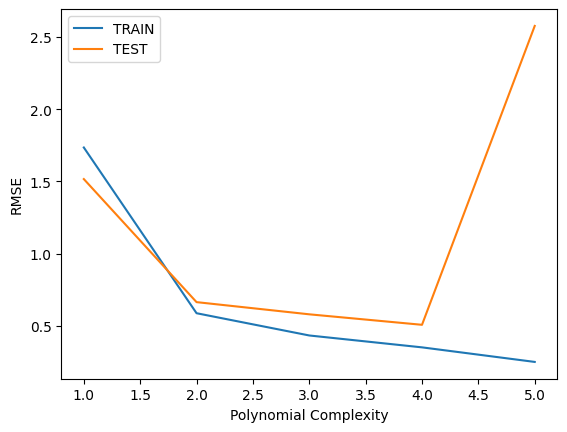

In [53]:
# eerst een zoom in in de eerste 5 resultaten
plt.plot(range(1,6),train_rmse_errors[:5],label='TRAIN')
plt.plot(range(1,6),test_rmse_errors[:5],label='TEST')
plt.xlabel("Polynomial Complexity")
plt.ylabel("RMSE")
plt.legend()

Rond de vierde graad explodeert de fout op de test set.  Welke waarde is optimaal? 2? 3? 4? Hier komt kennis inzake de materie kijken.  Hoe groot is de kans dat er meer informatie komt uit deze advertising dataset komt door naar de vierde macht te gaan? Wellicht is een derde macht al overkill en is een tweede macht voldoende. 

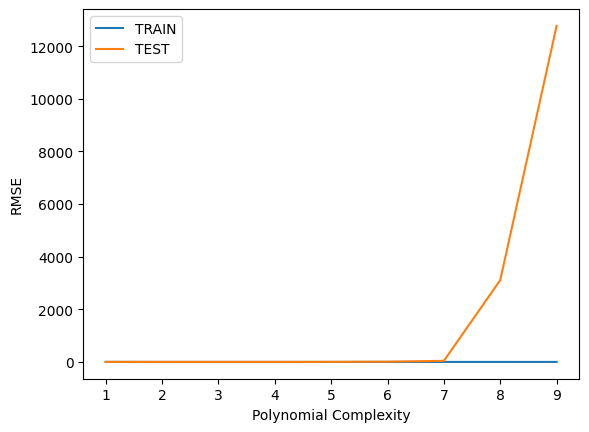

In [52]:
# volledige set - zo hoog ga je normaal nooit bij zo'n eenvoudige dataset:
plt.plot(range(1,10),train_rmse_errors,label='TRAIN')
plt.plot(range(1,10),test_rmse_errors,label='TEST')
plt.xlabel("Polynomial Complexity")
plt.ylabel("RMSE")
plt.legend()

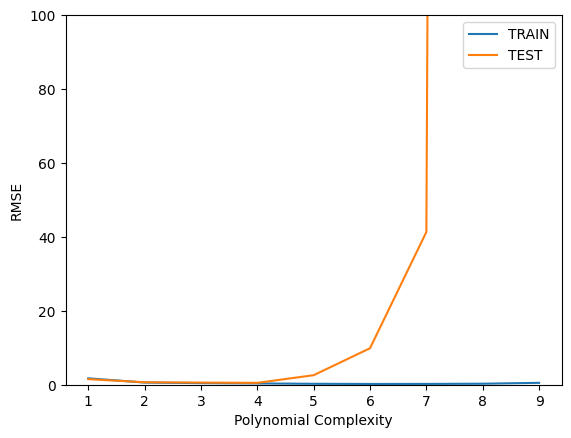

In [54]:
plt.plot(range(1,10),train_rmse_errors,label='TRAIN')
plt.plot(range(1,10),test_rmse_errors,label='TEST')
plt.xlabel("Polynomial Complexity")
plt.ylabel("RMSE")
plt.ylim(0,100)
plt.legend()

## Finale keuze van het model

Er zijn nu 2 zaken die we moeten opslaan: de Polynomial Feature Creator en het getrainde model zelf. Hoe doen we dit?

1. Kies de finale parameters, gebaseerd op de evaluaties 
2. Hertrain op alle data
3. Bewaar het Polynomial Converter object
4. Bewaar het Model

In [ ]:
# Op basis van de grafiek hogerop zouden we naar graad 4 kunnen gaan,
# maar we kiezen een veilige marge om niet te complex te gaan
# na 4 gaat het snel omhoog
final_poly_converter = PolynomialFeatures(degree=3, include_bias=False)

In [56]:
final_model = LinearRegression()

In [57]:
X_converted = final_poly_converter.fit_transform(X)

In [58]:
final_model.fit(X_converted,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Bewaren van het Model en de Converter

In [59]:
from joblib import dump, load

In [60]:
dump(final_model, 'sales_poly_model.joblib') 

['sales_poly_model.joblib']

In [61]:
dump(final_poly_converter,'poly_converter.joblib')

['poly_converter.joblib']

## Deployment en Voorspellingen

### Voorspelling op nieuwe data
Alle nieuwe data moet worden **geconverteerd** naar polynomiale data, aangezien ons model daarmee is getraind.  We laden onze converter die we eerder hebben opgeslagen, en gebruiken **.transform()** op de nieuwe data, aangezien we niet opnieuw fitten op een nieuwe dataset.

**Onze volgende marketing campagne zal 149 spenderen aan TV, 22 aan Radio, en 12 aan Newspaper advertenties.  Hoeveel sales kunnen we hiermee verwachten?**

In [63]:
loaded_poly = load('output/poly_converter.joblib')
loaded_model = load('output/sales_poly_model.joblib')

c:\Users\Cursist\DataScienceCourse\DS_Projects\venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator PolynomialFeatures from version 1.3.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Cursist\DataScienceCourse\DS_Projects\venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LinearRegression from version 1.3.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [64]:
campaign = [[149, 22, 12]]
columns = ['TV', 'radio', 'newspaper']
new_datapoint = pd.DataFrame(campaign, columns=columns)

In [65]:
campaign_poly = loaded_poly.transform(new_datapoint)

In [66]:
campaign_poly

array([[1.490000e+02, 2.200000e+01, 1.200000e+01, 2.220100e+04,
        3.278000e+03, 1.788000e+03, 4.840000e+02, 2.640000e+02,
        1.440000e+02, 3.307949e+06, 4.884220e+05, 2.664120e+05,
        7.211600e+04, 3.933600e+04, 2.145600e+04, 1.064800e+04,
        5.808000e+03, 3.168000e+03, 1.728000e+03]])

In [67]:
final_model.predict(campaign_poly)

array([14.64501014])

-----
---